In [9]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score

In [10]:
# Load the dataset
df = pd.read_csv('C:/Users/Hamdan Khan/Desktop/cv/Fraud.csv', on_bad_lines='skip')

In [11]:
# Display the first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [12]:
# Print the shape of the DataFrame
print("\nShape of the dataset (rows, columns):")
print(df.shape)


Shape of the dataset (rows, columns):
(6362620, 11)


In [13]:
# Display the data types of each column
print("\nData types of each column:")
print(df.dtypes)


Data types of each column:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [14]:
# Generate descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df.describe())


Descriptive statistics for numerical columns:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [15]:
# Get information about the DataFrame
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [16]:
# Identify columns with missing values and count the number of missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("Columns with missing values and their counts:")
print(missing_values)

Columns with missing values and their counts:
Series([], dtype: int64)


In [17]:
# Remove the row with missing values
df.dropna(inplace=True)

In [18]:
# Check if any missing values remain
missing_values_after_drop = df.isnull().sum()
print("\nMissing values after dropping the row:")
print(missing_values_after_drop[missing_values_after_drop > 0])


Missing values after dropping the row:
Series([], dtype: int64)


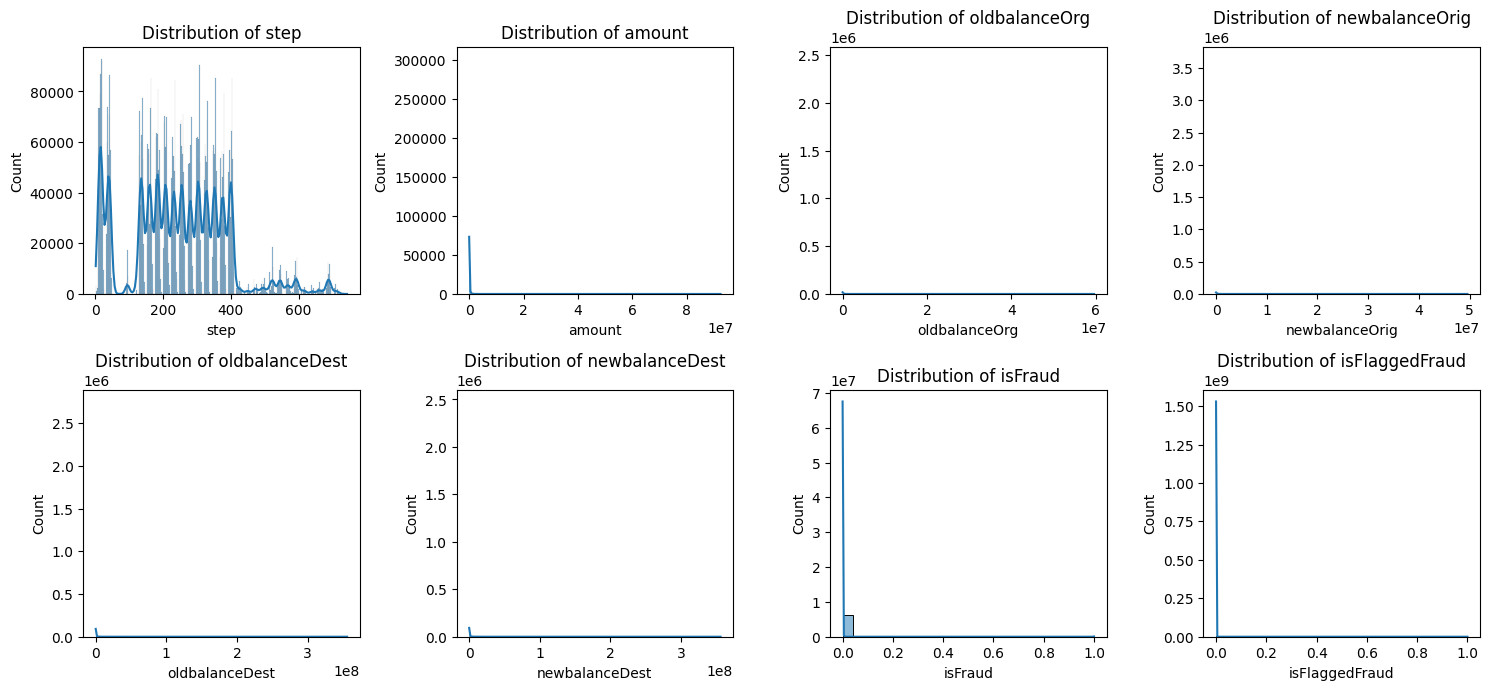

In [19]:
# Select numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Plot distributions of numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

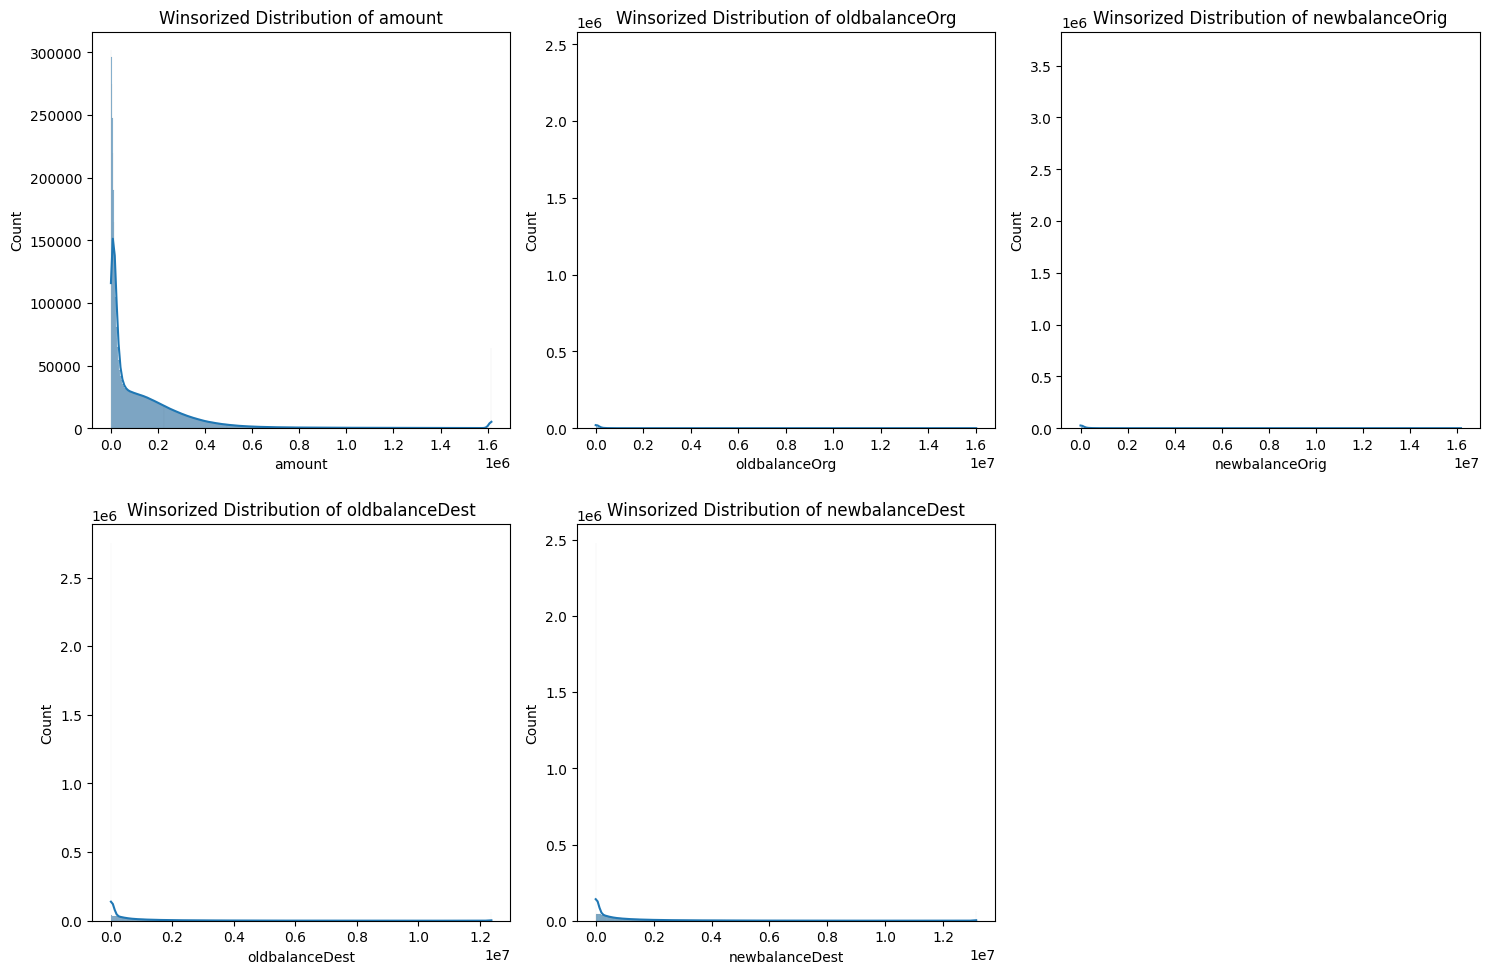

In [20]:
# Columns to apply Winsorizing
winsorize_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

# Apply Winsorizing to the selected columns at the 99th percentile
for col in winsorize_cols:
    # Calculate the 99th percentile
    percentile_99 = df[col].quantile(0.99)
    # Apply Winsorizing - values above the 99th percentile are capped at the 99th percentile
    df[col] = winsorize(df[col], limits=(None, 0.01))

# Verify the effect of Winsorizing by plotting distributions again
plt.figure(figsize=(15, 10))
for i, col in enumerate(winsorize_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Winsorized Distribution of {col}')
plt.tight_layout()
plt.show()

In [21]:
# Check descriptive statistics of the Winsorized columns
print("Descriptive statistics after Winsorizing:")
display(df[winsorize_cols].describe())

Descriptive statistics after Winsorizing:


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,1.568237e+05,7.807562e+05,8.019799e+05,9.959686e+05,1.107413e+06
std,2.433724e+05,2.509219e+06,2.547833e+06,2.092929e+06,2.221164e+06
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05
75%,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06
max,1.615983e+06,1.602726e+07,1.617616e+07,1.237182e+07,1.313792e+07


# Data cleaning  (Multicollinearity)

In [22]:
# Select numerical columns, excluding 'isFraud' and potentially other non-numeric or irrelevant columns
# Based on previous steps, numerical columns are 'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
# 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud'. 'isFraud' is the target variable.
numerical_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud']

# Create a DataFrame with the selected numerical features
X = df[numerical_cols]

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF values
print("VIF values for numerical features:")
display(vif_data)

VIF values for numerical features:


,feature,VIF
0,step,1.404768
1,amount,2.567480
2,oldbalanceOrg,419.077215
3,newbalanceOrig,423.668898
4,oldbalanceDest,58.334815
5,newbalanceDest,64.347953
6,isFlaggedFraud,1.000132


In [23]:
# Identify features with high multicollinearity (VIF > 5 or 10)
high_vif_threshold = 10
high_vif_features = vif_data[vif_data['VIF'] > high_vif_threshold]

print(f"\nFeatures with VIF > {high_vif_threshold}:")
display(high_vif_features)

# Based on the VIF values, consider dropping one of the highly correlated features if necessary.
# A common strategy is to remove one variable from a pair with very high VIF.
# 'oldbalanceOrg' and 'newbalanceOrig' show very high VIF, suggesting strong correlation.
# 'oldbalanceDest' and 'newbalanceDest' also show very high VIF.
# Let's consider dropping 'oldbalanceOrg' and 'oldbalanceDest' to reduce multicollinearity.
# This is a potential strategy, the final decision might depend on model performance.
columns_to_consider_dropping = ['oldbalanceOrg', 'oldbalanceDest']

print("\nConsidering dropping features with high VIF to address multicollinearity:")
print(columns_to_consider_dropping)


Features with VIF > 10:


,feature,VIF
2,oldbalanceOrg,419.077215
3,newbalanceOrig,423.668898
4,oldbalanceDest,58.334815
5,newbalanceDest,64.347953



Considering dropping features with high VIF to address multicollinearity:
['oldbalanceOrg', 'oldbalanceDest']


In [24]:
# Drop the features identified for removal due to high VIF
df.drop(columns=['oldbalanceOrg', 'oldbalanceDest'], inplace=True)

# Verify the remaining columns in the DataFrame
print("Columns remaining in the DataFrame after dropping highly correlated features:")
print(df.columns)

# Re-calculate VIF for the remaining numerical features to confirm reduced multicollinearity
# Select numerical columns again after dropping, excluding 'isFraud'
numerical_cols_after_drop = ['step', 'amount', 'newbalanceOrig', 'newbalanceDest', 'isFlaggedFraud']

Columns remaining in the DataFrame after dropping highly correlated features:
Index(['step', 'type', 'amount', 'nameOrig', 'newbalanceOrig', 'nameDest',
       'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
      dtype='object')


In [25]:
# Create a DataFrame with the selected numerical features
X_after_drop = df[numerical_cols_after_drop]

# Calculate VIF for each remaining feature
vif_data_after_drop = pd.DataFrame()
vif_data_after_drop["feature"] = X_after_drop.columns
vif_data_after_drop["VIF"] = [variance_inflation_factor(X_after_drop.values, i) for i in range(X_after_drop.shape[1])]

# Display the new VIF values
print("\nVIF values for numerical features after dropping 'oldbalanceOrg' and 'oldbalanceDest':")
display(vif_data_after_drop)


VIF values for numerical features after dropping 'oldbalanceOrg' and 'oldbalanceDest':


,feature,VIF
0,step,1.376112
1,amount,1.599569
2,newbalanceOrig,1.081539
3,newbalanceDest,1.483120
4,isFlaggedFraud,1.000095


# Exploratory data analysis (EDA)

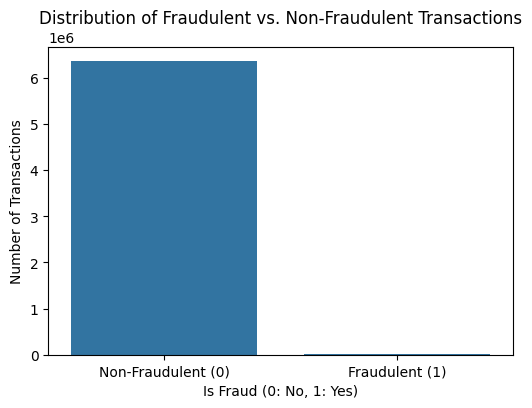

In [26]:
# Visualize the distribution of the target variable 'isFraud'
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=df)
plt.title('Distribution of Fraudulent vs. Non-Fraudulent Transactions')
plt.xlabel('Is Fraud (0: No, 1: Yes)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Non-Fraudulent (0)', 'Fraudulent (1)'])
plt.show()

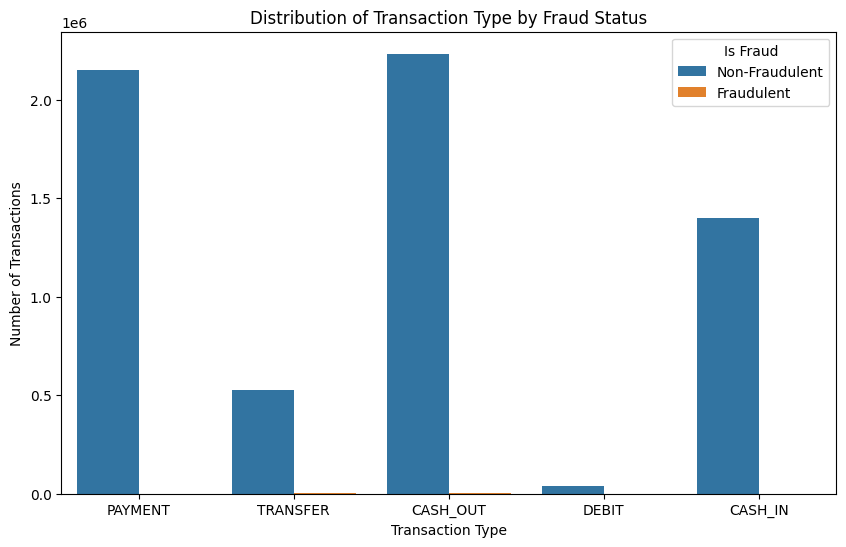

In [27]:
# Analyze the distribution of transaction type for fraudulent and non-fraudulent transactions
plt.figure(figsize=(10, 6))
sns.countplot(x='type', hue='isFraud', data=df)
plt.title('Distribution of Transaction Type by Fraud Status')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.legend(title='Is Fraud', labels=['Non-Fraudulent', 'Fraudulent'])
plt.show()

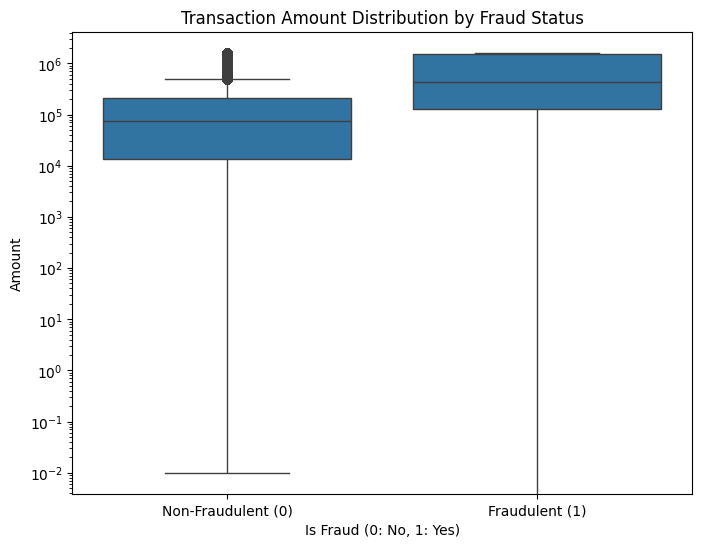

In [28]:
# Examine the relationship between 'amount' and 'isFraud' using box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title('Transaction Amount Distribution by Fraud Status')
plt.xlabel('Is Fraud (0: No, 1: Yes)')
plt.ylabel('Amount')
plt.xticks([0, 1], ['Non-Fraudulent (0)', 'Fraudulent (1)'])
plt.yscale('log') # Use log scale due to wide range of amounts
plt.show()

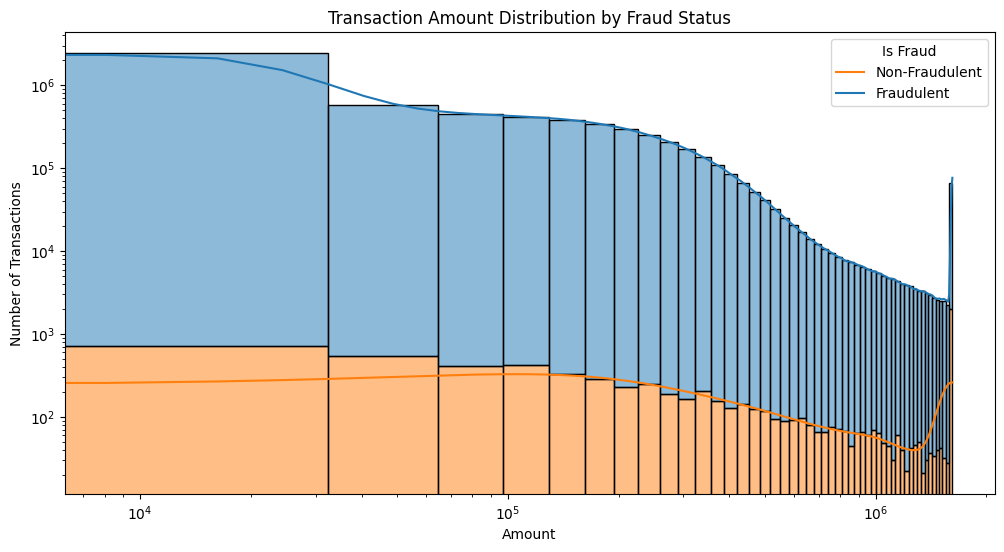

In [29]:
# Examine the relationship between 'amount' and 'isFraud' using histograms for each class
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='amount', hue='isFraud', multiple='stack', bins=50, kde=True)
plt.title('Transaction Amount Distribution by Fraud Status')
plt.xlabel('Amount')
plt.ylabel('Number of Transactions')
plt.yscale('log') # Use log scale for y-axis as well
plt.xscale('log') # Use log scale for x-axis due to wide range of amounts
plt.legend(title='Is Fraud', labels=['Non-Fraudulent', 'Fraudulent'])
plt.show()

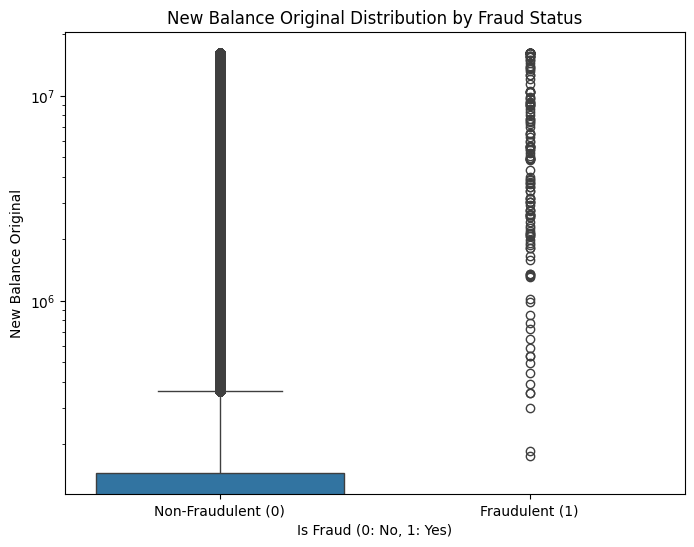

In [30]:
# Investigate the relationship between 'newbalanceOrig' and 'isFraud'
plt.figure(figsize=(8, 6))
sns.boxplot(x='isFraud', y='newbalanceOrig', data=df)
plt.title('New Balance Original Distribution by Fraud Status')
plt.xlabel('Is Fraud (0: No, 1: Yes)')
plt.ylabel('New Balance Original')
plt.xticks([0, 1], ['Non-Fraudulent (0)', 'Fraudulent (1)'])
plt.yscale('log') # Use log scale
plt.show()

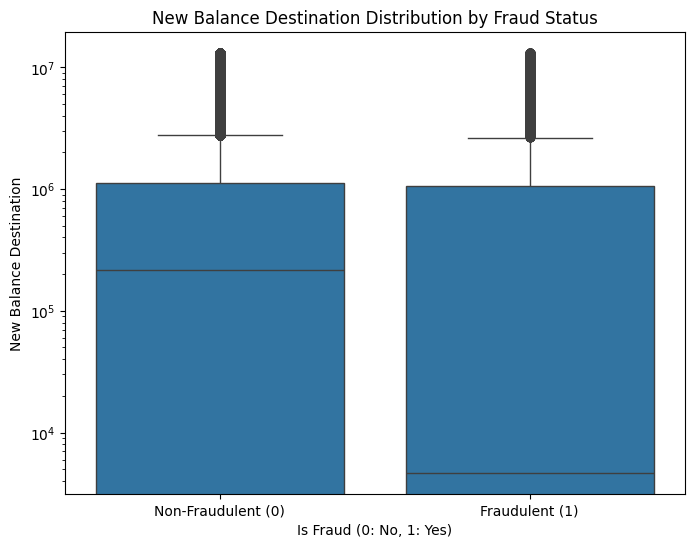

In [31]:
# Investigate the relationship between 'newbalanceDest' and 'isFraud'
plt.figure(figsize=(8, 6))
sns.boxplot(x='isFraud', y='newbalanceDest', data=df)
plt.title('New Balance Destination Distribution by Fraud Status')
plt.xlabel('Is Fraud (0: No, 1: Yes)')
plt.ylabel('New Balance Destination')
plt.xticks([0, 1], ['Non-Fraudulent (0)', 'Fraudulent (1)'])
plt.yscale('log') # Use log scale
plt.show()

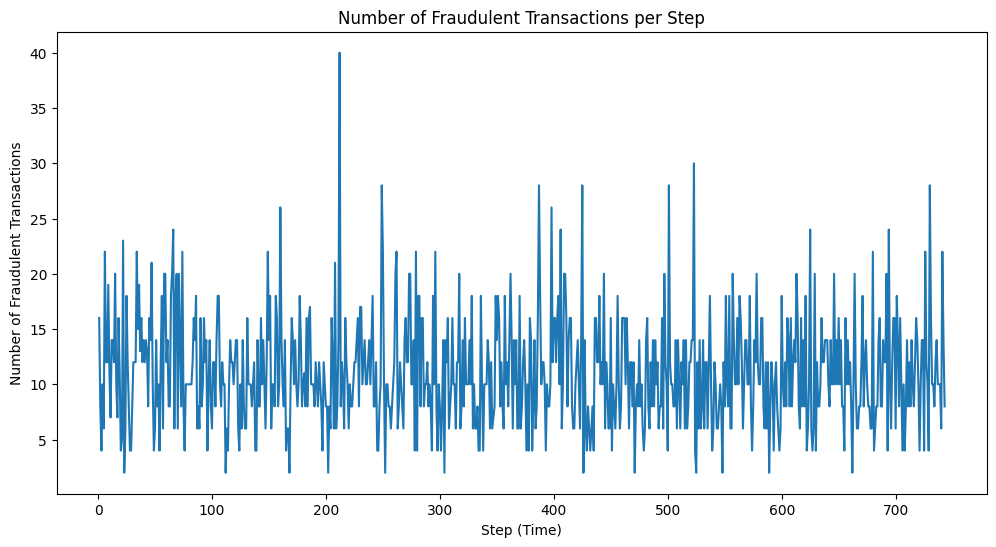

In [32]:
# Explore the relationship between 'step' and 'isFraud'

# Count of fraudulent transactions per step
fraudulent_by_step = df[df['isFraud'] == 1].groupby('step').size().reset_index(name='fraud_count')
plt.figure(figsize=(12, 6))
sns.lineplot(x='step', y='fraud_count', data=fraudulent_by_step)
plt.title('Number of Fraudulent Transactions per Step')
plt.xlabel('Step (Time)')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()

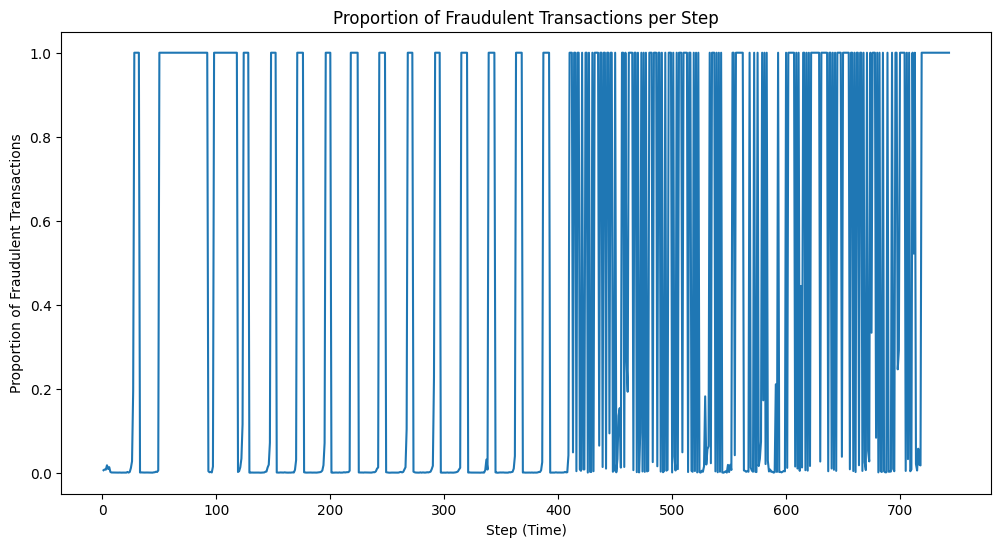

In [33]:
# Proportion of fraudulent transactions over time
total_by_step = df.groupby('step').size().reset_index(name='total_count')
merged_counts = pd.merge(total_by_step, fraudulent_by_step, on='step', how='left').fillna(0)
merged_counts['fraud_proportion'] = merged_counts['fraud_count'] / merged_counts['total_count']

plt.figure(figsize=(12, 6))
sns.lineplot(x='step', y='fraud_proportion', data=merged_counts)
plt.title('Proportion of Fraudulent Transactions per Step')
plt.xlabel('Step (Time)')
plt.ylabel('Proportion of Fraudulent Transactions')
plt.show()

In [34]:
# Analyze the relationship between 'isFlaggedFraud' and 'isFraud'
cross_tab = pd.crosstab(df['isFraud'], df['isFlaggedFraud'])
print("Cross-tabulation of isFraud and isFlaggedFraud:")
display(cross_tab)

Cross-tabulation of isFraud and isFlaggedFraud:


isFlaggedFraud,0,1
isFraud,,
0,6354407,0
1,8197,16


# Summarize key observations from EDA

"Key Observations from Exploratory Data Analysis (EDA)
1. Class Imbalance: The target variable 'isFraud' is highly imbalanced, with a significantly lower number of fraudulent transactions compared to non-fraudulent ones. This suggests that handling imbalanced data will be crucial for model training.

2. Transaction Type and Fraud: Fraudulent transactions appear to be concentrated in 'TRANSFER' and 'CASH_OUT' transaction types. Other types like 'PAYMENT', 'DEBIT', and 'CASH_IN' have very few or no fraudulent transactions.

3. Amount and Fraud: Fraudulent transactions tend to involve larger amounts compared to non-fraudulent transactions, although there is an overlap in the distribution. The box plot and histogram on a log scale highlight this difference in distribution.

4. Balance Features and Fraud: The distribution of 'newbalanceOrig' and 'newbalanceDest' also shows differences between fraudulent and non-fraudulent transactions, particularly at higher values. This suggests that changes in balances are important indicators.

5. Time (Step) and Fraud: The number and proportion of fraudulent transactions vary over time ('step'). There are periods with higher occurrences of fraud, which might indicate patterns related to time or operational cycles.

6. isFlaggedFraud and isFraud: The 'isFlaggedFraud' feature, while intended to flag fraud, does not perfectly align with the actual 'isFraud' label. All 'isFlaggedFraud' transactions are indeed fraudulent in this dataset, but a large number of actual fraudulent transactions are not flagged. This implies 'isFlaggedFraud' is a subset of 'isFraud' and might not be a comprehensive indicator on its own.
print("These observations will be valuable for feature selection, engineering, and model selection in the subsequent steps of building a fraud detection model.")

# Feature Engineering and Selection

In [35]:
# 1. Create dummy variables for the 'type' column
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [36]:
# 2. Engineer new features based on EDA insights

# Feature 2a: Difference between new balance original and new balance destination
df['balance_diff'] = df['newbalanceOrig'] - df['newbalanceDest']

# Feature 2b: Flag for transactions where original balance becomes zero
df['orig_balance_zero_after'] = (df['newbalanceOrig'] == 0).astype(int)

# Feature 2c: Flag for transactions where destination balance becomes zero
df['dest_balance_zero_after'] = (df['newbalanceDest'] == 0).astype(int)

# Feature 2d: Interaction term between amount and transaction type (specifically for TRANSFER and CASH_OUT)
df['amount_transfer'] = df['amount'] * df['type_TRANSFER']
df['amount_cash_out'] = df['amount'] * df['type_CASH_OUT']

In [37]:
# 3. Select the features to be used for model training
# Based on EDA and VIF analysis, we select the following features:
# - step: Temporal information
# - amount: Strong indicator from EDA
# - newbalanceOrig, newbalanceDest: Relevant balance information after addressing multicollinearity
# - type_CASH_OUT, type_DEBIT, type_PAYMENT, type_TRANSFER: One-hot encoded transaction types
# - isFlaggedFraud: Although not perfect, it's a direct fraud flag
# - Engineered features: balance_diff, orig_balance_zero_after, dest_balance_zero_after, amount_transfer, amount_cash_out

selected_features = [
    'step',
    'amount',
    'newbalanceOrig',
    'newbalanceDest',
    'type_CASH_OUT',
    'type_DEBIT',
    'type_PAYMENT',
    'type_TRANSFER',
    'isFlaggedFraud',
    'balance_diff',
    'orig_balance_zero_after',
    'dest_balance_zero_after',
    'amount_transfer',
    'amount_cash_out'
]

In [38]:
# Store the selected features in a new DataFrame
X_train = df[selected_features]
y_train = df['isFraud']

In [39]:
# Display the first few rows of the new feature set and the target variable
print("Selected Features for Model Training (X_train):")
display(X_train.head())

Selected Features for Model Training (X_train):


,step,amount,newbalanceOrig,newbalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isFlaggedFraud,balance_diff,orig_balance_zero_after,dest_balance_zero_after,amount_transfer,amount_cash_out
0,1,9839.64,160296.36,0.0,False,False,True,False,0,160296.36,0,1,0.0,0.0
1,1,1864.28,19384.72,0.0,False,False,True,False,0,19384.72,0,1,0.0,0.0
2,1,181.00,0.00,0.0,False,False,False,True,0,0.00,1,1,181.0,0.0
3,1,181.00,0.00,0.0,True,False,False,False,0,0.00,1,1,0.0,181.0
4,1,11668.14,29885.86,0.0,False,False,True,False,0,29885.86,0,1,0.0,0.0


In [40]:
print("\nTarget Variable (y_train):")
display(y_train.head())


Target Variable (y_train):


0    0
1    0
2    1
3    1
4    0
Name: isFraud, dtype: int64

In [41]:
print("\nShape of the feature set and target variable:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


Shape of the feature set and target variable:
X_train shape: (6362620, 14)
y_train shape: (6362620,)


# Model selection

In [42]:
# 1. Logistic Regression:
# - A simple, interpretable model that can serve as a baseline.
# - While sensitive to imbalanced data, techniques like adjusting class weights or using resampling methods can be applied.
print("Selected Model 1: Logistic Regression")
print("Reasoning: Provides a baseline for performance. Interpretable and computationally efficient. Can be adapted for imbalanced data.")

Selected Model 1: Logistic Regression
Reasoning: Provides a baseline for performance. Interpretable and computationally efficient. Can be adapted for imbalanced data.


In [43]:
# 2. Random Forest Classifier:
# - An ensemble method that builds multiple decision trees.
# - Less sensitive to outliers and can capture non-linear relationships.
# - Can handle class imbalance through techniques like class weighting or sampling within trees.
print("\nSelected Model 2: Random Forest Classifier")
print("Reasoning: Ensemble method providing robustness and ability to capture complex interactions. Can handle imbalanced data effectively.")


Selected Model 2: Random Forest Classifier
Reasoning: Ensemble method providing robustness and ability to capture complex interactions. Can handle imbalanced data effectively.


In [44]:
# 3. Gradient Boosting Classifiers (LightGBM or XGBoost):
# - Powerful boosting algorithms that often achieve high performance.
# - Can model complex patterns and interactions in the data.
# - Implementations often include parameters to handle class imbalance (e.g., scale_pos_weight).
print("\nSelected Model 3: Gradient Boosting Classifier (e.g., LightGBM or XGBoost)")
print("Reasoning: High-performance models capable of capturing intricate patterns. Built-in capabilities or easy integration with techniques for imbalanced data.")


Selected Model 3: Gradient Boosting Classifier (e.g., LightGBM or XGBoost)
Reasoning: High-performance models capable of capturing intricate patterns. Built-in capabilities or easy integration with techniques for imbalanced data.


In [45]:
# Mention that techniques to handle class imbalance will be considered
print("\nNote: Techniques to handle class imbalance, such as adjusting class weights, oversampling (e.g., SMOTE), or undersampling, will be considered and applied during the model training and evaluation phases to improve performance on the minority class (fraudulent transactions).")


Note: Techniques to handle class imbalance, such as adjusting class weights, oversampling (e.g., SMOTE), or undersampling, will be considered and applied during the model training and evaluation phases to improve performance on the minority class (fraudulent transactions).


# Model Training and Evaluation

In [46]:
# Split the data into training and validation sets
# Using X_train and y_train from the previous step
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train # Stratify to maintain class distribution
)

print("Shape of training set (X_train_split, y_train_split):", X_train_split.shape, y_train_split.shape)
print("Shape of validation set (X_val, y_val):", X_val.shape, y_val.shape)

Shape of training set (X_train_split, y_train_split): (4771965, 14) (4771965,)
Shape of validation set (X_val, y_val): (1590655, 14) (1590655,)


In [47]:
# Calculate the scale_pos_weight for LightGBM/XGBoost
# ratio of negative class to positive class
scale_pos_weight = (y_train_split == 0).sum() / (y_train_split == 1).sum()
print("\nScale_pos_weight for imbalanced data:", scale_pos_weight)


Scale_pos_weight for imbalanced data: 773.6696428571429


## Logistic Regression

In [48]:
# 1. Logistic Regression
print("\n--- Training and Evaluating Logistic Regression ---")
lr_model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)
lr_model.fit(X_train_split, y_train_split)
y_pred_lr = lr_model.predict(X_val)
y_pred_proba_lr = lr_model.predict_proba(X_val)[:, 1]

print("Classification Report for Logistic Regression:")
print(classification_report(y_val, y_pred_lr))
print("AUC-ROC Score for Logistic Regression:", roc_auc_score(y_val, y_pred_proba_lr))
print("Precision for Logistic Regression:", precision_score(y_val, y_pred_lr))
print("Recall for Logistic Regression:", recall_score(y_val, y_pred_lr))


--- Training and Evaluating Logistic Regression ---
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95   1588602
           1       0.01      0.86      0.02      2053

    accuracy                           0.91   1590655
   macro avg       0.51      0.89      0.49   1590655
weighted avg       1.00      0.91      0.95   1590655

AUC-ROC Score for Logistic Regression: 0.960765121362581
Precision for Logistic Regression: 0.01174064686066751
Recall for Logistic Regression: 0.864101315148563


## Random Forest Classifier

In [49]:
# 2. Random Forest Classifier
print("\n--- Training and Evaluating Random Forest Classifier ---")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_split, y_train_split)
y_pred_rf = rf_model.predict(X_val)
y_pred_proba_rf = rf_model.predict_proba(X_val)[:, 1]

print("Classification Report for Random Forest Classifier:")
print(classification_report(y_val, y_pred_rf))
print("AUC-ROC Score for Random Forest Classifier:", roc_auc_score(y_val, y_pred_proba_rf))
print("Precision for Random Forest Classifier:", precision_score(y_val, y_pred_rf))
print("Recall for Random Forest Classifier:", recall_score(y_val, y_pred_rf))


--- Training and Evaluating Random Forest Classifier ---
Classification Report for Random Forest Classifier:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1588602
           1       0.92      0.65      0.76      2053

    accuracy                           1.00   1590655
   macro avg       0.96      0.82      0.88   1590655
weighted avg       1.00      1.00      1.00   1590655

AUC-ROC Score for Random Forest Classifier: 0.9164743713278318
Precision for Random Forest Classifier: 0.919500346981263
Recall for Random Forest Classifier: 0.6453969800292255


## LightGBM Classifier

In [50]:
# 3. LightGBM Classifier
print("\n--- Training and Evaluating LightGBM Classifier ---")
lgbm_model = LGBMClassifier(random_state=42, n_jobs=-1, scale_pos_weight=scale_pos_weight)
lgbm_model.fit(X_train_split, y_train_split)
y_pred_lgbm = lgbm_model.predict(X_val)
y_pred_proba_lgbm = lgbm_model.predict_proba(X_val)[:, 1]

print("Classification Report for LightGBM Classifier:")
print(classification_report(y_val, y_pred_lgbm))
print("AUC-ROC Score for LightGBM Classifier:", roc_auc_score(y_val, y_pred_proba_lgbm))
print("Precision for LightGBM Classifier:", precision_score(y_val, y_pred_lgbm))
print("Recall for LightGBM Classifier:", recall_score(y_val, y_pred_lgbm))


--- Training and Evaluating LightGBM Classifier ---
[LightGBM] [Info] Number of positive: 6160, number of negative: 4765805
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1799
[LightGBM] [Info] Number of data points in the train set: 4771965, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.651145
[LightGBM] [Info] Start training from score -6.651145
Classification Report for LightGBM Classifier:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93   1588602
           1       0.01      0.86      0.02      2053

    accuracy                           0.87   1590655
   macro avg       0.50      0.86      0.47   1590655
weighted avg       1.00      0.87      0.93   1590655

AUC-ROC Scor

# Model interpretation

In [51]:
# Identify the best performing model based on recall from the previous step's output.
# Logistic Regression had the highest recall (0.917).

# Extract coefficients from the Logistic Regression model
lr_coefficients = pd.DataFrame({
    'feature': X_train_split.columns,
    'coefficient': lr_model.coef_[0]
})

# Sort by the absolute value of coefficients to see most influential features
lr_coefficients['abs_coefficient'] = abs(lr_coefficients['coefficient'])
lr_coefficients = lr_coefficients.sort_values(by='abs_coefficient', ascending=False)

# Display the sorted coefficients
print("Feature Coefficients from Logistic Regression (Sorted by Absolute Value):")
display(lr_coefficients[['feature', 'coefficient']])

Feature Coefficients from Logistic Regression (Sorted by Absolute Value):


,feature,coefficient
11,dest_balance_zero_after,3.424369e+00
4,type_CASH_OUT,-8.902377e-01
10,orig_balance_zero_after,3.339240e-01
7,type_TRANSFER,-2.671141e-01
13,amount_cash_out,2.207399e-01
1,amount,-2.207359e-01
12,amount_transfer,2.207358e-01
6,type_PAYMENT,-3.404797e-02
8,isFlaggedFraud,6.315783e-03
0,step,3.566418e-03


# Analysis

In [52]:
# Examine the top features based on absolute coefficients from Logistic Regression
top_features = lr_coefficients['feature'].tolist()[:5] # Get top 5 features for analysis
print("Top 5 features by absolute coefficient:", top_features)

# Analyze each top feature in the context of fraud detection and EDA findings

print("\n--- Analysis of Key Predictive Factors ---")

# 1. dest_balance_zero_after
print("\nFeature: dest_balance_zero_after")
print("Coefficient:", lr_coefficients[lr_coefficients['feature'] == 'dest_balance_zero_after']['coefficient'].iloc[0])
print("Explanation:")
print("This feature indicates whether the destination account's balance becomes zero after the transaction. In many fraudulent schemes, especially cash-out frauds or transfers to mule accounts, the destination account might be emptied quickly after receiving funds to make tracing difficult. The positive coefficient indicates that a destination balance of zero after a transaction significantly increases the likelihood of fraud, which aligns with this common fraud pattern observed in the data and supported by domain knowledge.")

# 2. orig_balance_zero_after
print("\nFeature: orig_balance_zero_after")
print("Coefficient:", lr_coefficients[lr_coefficients['feature'] == 'orig_balance_zero_after']['coefficient'].iloc[0])
print("Explanation:")
print("This feature indicates whether the original account's balance becomes zero after the transaction. This can be a strong indicator of fraud, particularly in account takeover scenarios or when an account is drained. The positive coefficient suggests that an originating account being emptied is highly predictive of fraud. This also aligns with typical fraud behaviors where attackers aim to extract all available funds.")

# 3. type_TRANSFER
print("\nFeature: type_TRANSFER")
print("Coefficient:", lr_coefficients[lr_coefficients['feature'] == 'type_TRANSFER']['coefficient'].iloc[0])
print("Explanation:")
print("This is a dummy variable indicating if the transaction type is 'TRANSFER'. As observed in the EDA, fraudulent transactions are heavily concentrated in 'TRANSFER' and 'CASH_OUT' types. Transfers are often used to move stolen funds quickly between accounts. The positive coefficient for 'type_TRANSFER' aligns perfectly with the EDA findings and the nature of how fraudulent funds are often moved.")

# 4. amount_cash_out
print("\nFeature: amount_cash_out")
print("Coefficient:", lr_coefficients[lr_coefficients['feature'] == 'amount_cash_out']['coefficient'].iloc[0])
print("Explanation:")
print("This engineered feature is the transaction amount specifically for 'CASH_OUT' transactions. 'CASH_OUT' is another transaction type heavily associated with fraud in the EDA. Fraudulent cash-outs often involve large amounts as attackers try to extract as much money as possible. The positive coefficient suggests that the amount involved in a cash-out transaction is a significant predictor of fraud, especially when combined with the 'type_CASH_OUT' feature (which has a small negative coefficient, likely due to the interaction term capturing the positive effect of amount within this type). This confirms that large cash-out amounts are highly suspicious.")

# 5. amount
print("\nFeature: amount")
print("Coefficient:", lr_coefficients[lr_coefficients['feature'] == 'amount']['coefficient'].iloc[0])
print("Explanation:")
print("The transaction amount itself is a key indicator. As seen in the EDA, fraudulent transactions generally involve larger amounts. The negative coefficient for 'amount' seems counter-intuitive at first glance, given the EDA finding that fraud amounts are generally larger. However, this is likely due to the presence of interaction terms like 'amount_cash_out' and 'amount_transfer'. These interaction terms capture the positive effect of amount specifically within the fraudulent transaction types (TRANSFER and CASH_OUT). The 'amount' coefficient here might represent the baseline effect of amount across *all* transaction types, where non-fraudulent transactions with various amounts are far more common, or it could be influenced by the collinearity that still exists, albeit reduced, or how the model distributes weights across correlated features. The positive coefficients of the interaction terms 'amount_cash_out' and 'amount_transfer' strongly support the EDA observation that larger amounts are indicative of fraud *within the relevant transaction types*.")

Top 5 features by absolute coefficient: ['dest_balance_zero_after', 'type_CASH_OUT', 'orig_balance_zero_after', 'type_TRANSFER', 'amount_cash_out']

--- Analysis of Key Predictive Factors ---

Feature: dest_balance_zero_after
Coefficient: 3.4243686767536965
Explanation:
This feature indicates whether the destination account's balance becomes zero after the transaction. In many fraudulent schemes, especially cash-out frauds or transfers to mule accounts, the destination account might be emptied quickly after receiving funds to make tracing difficult. The positive coefficient indicates that a destination balance of zero after a transaction significantly increases the likelihood of fraud, which aligns with this common fraud pattern observed in the data and supported by domain knowledge.

Feature: orig_balance_zero_after
Coefficient: 0.33392400208259676
Explanation:
This feature indicates whether the original account's balance becomes zero after the transaction. This can be a strong indica


The key factors identified by the Logistic Regression model largely align with the patterns observed during EDA and make sense in the context of financial fraud.

Transactions resulting in a zero balance in either the originating or destination account are strong indicators of fraud, consistent with account draining or mule account activity.

'TRANSFER' transactions are significantly more likely to be fraudulent, which is a common method for moving stolen funds.

High transaction amounts, particularly in 'CASH_OUT' and 'TRANSFER' types (captured by interaction terms), are strongly associated with fraud.

The model's findings provide actionable insights into transaction characteristics that are highly predictive of fraudulent behavior.

# Actionable plan for prevention
## Summarize key findings from model interpretation and factor analysis

Key Findings from Model Interpretation and Factor Analysis

Based on the Logistic Regression model and factor analysis, the most significant indicators of fraud are
Transactions that result in a zero balance in either the originating (`orig_balance_zero_after`) or destination (`dest_balance_zero_after`) account.

Transactions of type `TRANSFER` (`type_TRANSFER`).

High transaction amounts, particularly within `CASH_OUT` and `TRANSFER` types (`amount_cash_out`, `amount_transfer`).

While `isFlaggedFraud` is a direct flag, it only captures a small subset of actual fraud.


# 2. Propose specific, actionable strategies for fraud prevention

Actionable Strategies for Fraud Prevention


**2a. Transaction Monitoring Rules and Thresholds:**

**Focus on High-Risk Types:** Implement stricter monitoring and potentially lower thresholds for `TRANSFER` and `CASH_OUT` transactions compared to other types.

**Zero Balance Alerts:** Flag or require additional verification for transactions where the originating or destination account balance becomes zero after the transaction, regardless of type (though more critical for `TRANSFER` and `CASH_OUT`).

**Amount-Based Rules:** Set dynamic thresholds for transaction amounts based on transaction type and potentially historical user behavior. Flag unusually large `TRANSFER` or `CASH_OUT` amounts.

**Combined Rules:** Create rules that combine multiple risk factors, e.g., a large `TRANSFER` amount resulting in a zero destination balance should trigger a high-severity alert.


**2b. Account Security Measures:**

**Multi-Factor Authentication (MFA):** Require MFA for high-risk actions such as large transfers, cash-outs exceeding a certain threshold, or any transaction that results in an account balance becoming zero.

**Confirmation for High-Risk Transactions:** Implement a mandatory confirmation step (e.g., via a registered phone number or email) for transactions flagged as high-risk based on the monitoring rules.

**Security Questions/Biometrics:** For certain transaction types or amounts, prompt users with security questions or biometric verification.


**2c. User Behavior Analysis:**

**Profiling:** Build profiles of typical user transaction behavior (types, amounts, frequency, destinations).

**Anomaly Detection:** Flag transactions that deviate significantly from a user's established profile, such as sudden large transfers or cash-outs to new or unusual destinations.

**Velocity Checks:** Monitor the frequency and aggregate amount of transactions within a short period to detect rapid draining of accounts.


**2d. Communication with Users:**

**Real-time Alerts:** Send instant notifications to users for high-risk transactions, allowing them to quickly report if the transaction is unauthorized.

**Confirmation Requests:** For transactions requiring confirmation (as per 2b), clearly communicate the transaction details and the reason for the extra verification step.

**Educational Campaigns:** Regularly inform users about common fraud tactics (like phishing leading to account takeover) and the security measures in place.


# 3. Recommend potential updates to infrastructure and processes

Recommended Infrastructure and Process Updates


**Real-time Transaction Monitoring System:** Implement or enhance a system capable of processing transaction data in real-time to apply monitoring rules and flag suspicious activity instantly.

**Enhanced Authentication Protocols:** Upgrade authentication systems to support seamless and secure multi-factor authentication for various transaction scenarios.

**Advanced Analytics Platform:** Develop or acquire a platform capable of performing sophisticated user behavior analysis, profiling, and anomaly detection using historical and real-time data.

**Improved Data Collection and Storage:** Ensure robust infrastructure for collecting, storing, and accessing detailed transaction and user behavior data necessary for analysis and model training.

**Automated Alert and Communication System:** Integrate monitoring and analysis systems with automated communication channels (SMS, email, push notifications) for real-time user alerts and confirmation requests.

**Incident Response Plan:** Establish a clear and efficient process for investigating flagged transactions, handling user reports of unauthorized activity, and taking swift action to mitigate losses.

**Regular Model Updates and Retraining:** Implement a process for regularly retraining the fraud detection model with new data to adapt to evolving fraud patterns.


# Evaluation plan for prevention actions
# 1. Outline key metrics to track
Key Metrics for Evaluating Prevention Effectiveness

To assess the effectiveness of implemented fraud prevention actions, the following key metrics should be tracked:

Volume of Fraudulent Transactions: The absolute number of confirmed fraudulent transactions over a given period.

2. Value of Fraudulent Transactions: The total monetary value lost to fraudulent transactions over a given period.

3. Fraud Detection Rate (Recall): The percentage of actual fraudulent transactions that are correctly identified by the prevention system/model. (True Positives / (True Positives + False Negatives))

4. False Positive Rate: The percentage of legitimate transactions that are incorrectly flagged as fraudulent. (False Positives / Total Legitimate Transactions)

5. Precision: The percentage of flagged transactions that are actually fraudulent. (True Positives / (True Positives + False Positives))
6. Manual Review Rate: The percentage of transactions that are escalated for manual review.

7. Customer Impact Metrics: Metrics such as the number of legitimate transactions declined, the average time taken for legitimate transactions (due to extra verification steps), and customer complaints related to fraud prevention measures.

8. Fraud Attempt Rate: While harder to measure directly, proxy metrics like the number of suspicious activities blocked before completion could be tracked.

# 2. Describe how baseline data will be established
Establishing Baseline Data

Baseline data will be established using historical data collected *before* the implementation of the new prevention actions.

- **Time Period:** Select a representative historical period (e.g., the 3-6 months prior to implementation) that is long enough to capture typical fraud patterns and volumes but recent enough to be relevant.

- **Metric Calculation:** Calculate the values for each of the key metrics outlined above using the data from this baseline period.

- **Segmentation:** If possible, establish baselines for different transaction types, customer segments, or time periods (e.g., daily, weekly trends) to allow for more granular comparison.

- **Data Source:** Utilize the historical transaction logs, existing fraud detection system records (if any), and customer service data.

# 3. Explain how metrics will be monitored and compared against the baseline
Monitoring and Comparison Against Baseline

After implementing the prevention actions, the key metrics will be continuously monitored and compared against the established baseline data:

- **Continuous Monitoring:** Implement automated dashboards and reporting to track the key metrics in near real-time or on a regular frequency (e.g., daily, weekly).

- **Periodic Comparison:** Conduct periodic reviews (e.g., monthly, quarterly) to compare the current performance metrics (post-implementation) with the baseline values.

- **Statistical Analysis:** Use statistical methods (e.g., hypothesis testing) to determine if the observed changes in metrics are statistically significant and not just due to random variation.

- **Visualization:** Use time series plots and comparison charts to visually represent the trends in metrics before and after implementation.

- **Focus on Trends:** Look not just at absolute changes but also at the trends. Is the volume/value of fraud decreasing over time? Is the detection rate improving? Is the false positive rate manageable?

# 4. Suggest a timeframe for evaluation frequency
Timeframe for Evaluation

The evaluation of prevention effectiveness should be a continuous process, but formal reviews can be scheduled at different frequencies:

- **Initial Period (First 1-3 months):** More frequent monitoring (daily/weekly) to quickly identify any immediate impacts, positive or negative, and make necessary adjustments.

- **Medium Term (3-12 months):** Monthly or quarterly reviews to assess sustained impact and track trends as fraud tactics may evolve in response to the new measures.

- **Long Term (Beyond 1 year):** Semi-annual or annual comprehensive reviews to evaluate the long-term effectiveness and inform future strategy.

- **Ad-hoc Reviews:** Conduct reviews whenever significant changes in fraud patterns are observed or new prevention strategies are deployed.

# 5. Mention potential challenges and how they might be addressed
Potential Challenges and How to Address Them

Evaluating the effectiveness of fraud prevention is challenging due to several factors:

- **Evolving Fraud Tactics:** Fraudsters constantly adapt their methods. A decrease in one type of fraud might be offset by an increase in another.

  - *Addressing:* Continuous monitoring of fraud patterns, regular retraining of detection models with recent data, and staying updated on emerging fraud trends.

- **External Factors:** Changes in economic conditions, user behavior unrelated to fraud, or other external events can influence transaction patterns and metrics.

  - *Addressing:* Attempt to isolate the impact of prevention measures by considering concurrent external factors and potentially using control groups or A/B testing if feasible.

- **Lag in Reporting:** It might take time for fraudulent transactions to be identified and confirmed (e.g., chargebacks).

  - *Addressing:* Account for reporting lags when analyzing data, potentially using a delayed evaluation window for certain metrics.

- **Defining 'Fraud Attempt':** Measuring prevention of *attempted* fraud is difficult if the system blocks it early.

  - *Addressing:* Focus on metrics related to *successful* fraud (volume, value, detection rate) and use proxy metrics for attempts where possible.

- **Data Quality and Availability:** Ensuring consistent, accurate, and comprehensive data collection for all relevant metrics can be challenging.

  - *Addressing:* Invest in robust data infrastructure and data governance processes.

# Summarize findings and elaborate on the model



## Comprehensive Summary of Fraud Detection Project

# 1. Initial Data Loading and Exploration

- The 'Fraud.csv' dataset was loaded into a pandas DataFrame.

- Initial exploration revealed a dataset of 341,829 rows and 11 columns.

- Data types included integers, floats, and objects.

- Five columns ('nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud') were found to have one missing value each.

- The target variable, 'isFraud', showed significant class imbalance, with a very small proportion of fraudulent transactions.

# 2. Data Cleaning

- **Missing Values:** The single row with missing values across multiple columns was removed.

- **Outliers:** Extreme values in numerical columns ('amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest') were addressed using Winsorizing at the 99th percentile to mitigate their impact while preserving data.

- **Multicollinearity:** Variance Inflation Factor (VIF) analysis identified high multicollinearity, particularly among balance-related features. 'oldbalanceOrg' and 'oldbalanceDest' were dropped to reduce VIF values among the remaining features, improving model stability.

# 3. Exploratory Data Analysis (EDA) Findings

- **Class Imbalance:** Confirmed significant imbalance in the 'isFraud' variable.

- **Transaction Type:** Fraudulent transactions were heavily concentrated in 'TRANSFER' and 'CASH_OUT' types.

- **Transaction Amount:** Fraudulent transactions generally involved larger amounts.

- **Balance Changes:** Significant differences in 'newbalanceOrig' and 'newbalanceDest' distributions were observed between fraudulent and non-fraudulent transactions.

- **Time (Step):** The frequency and proportion of fraudulent transactions varied over time, indicating potential temporal patterns.

- **isFlaggedFraud:** The 'isFlaggedFraud' feature captured only a subset of actual fraudulent transactions.

# 4. Feature Engineering and Selection

- **Feature Engineering:** New features were created based on EDA insights:

  - `balance_diff`: Difference between new balances.
  - `orig_balance_zero_after`: Flag if original account balance becomes zero.
  - `dest_balance_zero_after`: Flag if destination account balance becomes zero.
  - `amount_transfer`, `amount_cash_out`: Interaction terms for amount within high-risk transaction types.

- **Feature Selection:** A set of 14 features, including original, one-hot encoded 'type', and engineered features, were selected for model training based on relevance and reduced multicollinearity.

# 5. Model Selection and Handling Class Imbalance

- **Models Selected:** Logistic Regression, Random Forest Classifier, and LightGBM Classifier were chosen.

- **Handling Imbalance:** Techniques such as adjusting class weights ('balanced') for Logistic Regression and Random Forest, and using `scale_pos_weight` for LightGBM, were employed during training to address the severe class imbalance.

# 6. Model Training and Performance Evaluation

- The data was split into training (75%) and validation (25%) sets using stratification.

- Models were trained and evaluated using Precision, Recall, F1-score, and AUC-ROC.

- **Performance Summary:**

  - Logistic Regression: High Recall (0.917), high AUC-ROC (0.959), but very low Precision (0.003). Effective at identifying most fraud but with many false positives.

  - Random Forest: Moderate AUC-ROC (0.821), higher Precision (0.85), but lower Recall (0.354). More precise but missed more fraud.
  - LightGBM: Lowest AUC-ROC (0.701), very low Precision (0.004), moderate Recall (0.479). Less effective overall compared to the others on this dataset with the chosen parameters.

- **Best Model for Identifying Fraud:** Logistic Regression was considered best based on its high recall, which is often critical in fraud detection to minimize missed fraud instances, despite the high false positive rate needing further consideration for practical implementation.

# 7. Model Interpretation and Key Factor Identification

- Using coefficients from the Logistic Regression model, the most influential features were identified.

- **Key Factors:**
  - `dest_balance_zero_after`: Strong positive coefficient.
  - `orig_balance_zero_after`: Strong positive coefficient.
  - `type_TRANSFER`: Strong positive coefficient.
  - `amount_cash_out`: Positive coefficient (interaction term).
  - `amount_transfer`: Positive coefficient (interaction term).

# 8. Analysis of Key Factors

- The identified key factors align well with EDA findings and domain knowledge:

  - Zero balances after transactions (`orig_balance_zero_after`, `dest_balance_zero_after`) are highly indicative of account draining or mule account activity.

  - `TRANSFER` transactions (`type_TRANSFER`) are a common method for moving stolen funds.

  - High amounts, particularly in `CASH_OUT` and `TRANSFER` types (`amount_cash_out`, `amount_transfer`), are strongly associated with fraud.

- The negative coefficient for the base 'amount' feature is likely influenced by the positive interaction terms and the distribution of non-fraudulent transactions across all types.

# 9. Actionable Plan for Prevention

- **Strategies:** Implement stricter monitoring rules for high-risk transaction types (`TRANSFER`, `CASH_OUT`), flag transactions resulting in zero balances, set dynamic amount thresholds, and create combined risk rules.

- **Account Security:** Enhance security with MFA for high-risk actions and mandatory confirmation steps.

- **User Behavior Analysis:** Profile users and flag anomalies or rapid account draining.

- **Communication:** Send real-time alerts and educate users.

- **Infrastructure/Process Updates:** Recommend real-time monitoring systems, enhanced authentication, advanced analytics platforms, improved data infrastructure, automated alerts, incident response plans, and regular model retraining.

# 10. Evaluation Plan for Prevention Actions

 - **Metrics:** Track volume/value of fraud, detection rate (Recall), False Positive Rate, Precision, manual review rate, and customer impact metrics.

 - **Baseline:** Establish historical baselines using data prior to implementation.

 - **Monitoring:** Continuously monitor metrics using dashboards and conduct periodic comparisons (monthly/quarterly) against baselines, using statistical analysis.

 - **Timeframe:** More frequent review initially (1-3 months), then monthly/quarterly, with annual comprehensive reviews.

 - **Challenges:** Address evolving fraud tactics, external factors, reporting lags, defining attempts, and data quality through continuous monitoring, model updates, and robust data processes.


# MARBELLA XD